In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# PARAMETERS

T_horizon = 1.0  # hours

lambda_B = 12  # buy limit intensity
lambda_S = 15  # sell limit intensity (not used in best bid queue)
lambda_M = 8   # market sell intensity

Q0 = 20  # initial queue depth

np.random.seed(42)

### Step 1: Simulate Arrival Times
For each order type (buy limit, sell limit, market sell):
1. Initialize t = 0.
2. Generate exponential inter-arrival time using inverse transform.
3. Update t = t + T.
4. Continue until t > T.

In [ ]:
def simulate_poisson_arrivals(lmbda, T):
    """
    Simulate arrival times using inverse transform method.
    """
    t = 0.0
    arrivals = []

    while True:
        U = np.random.uniform(0, 1)
        inter_arrival = -np.log(U) / lmbda
        t = t + inter_arrival

        if t > T:
            break

        arrivals.append(t)

    return np.array(arrivals)

### Step 2: Simulate Order Sizes
For every arrival generated in Step 1, simulate order size using the discrete
inverse transform procedure.

In [3]:
buy_times = simulate_poisson_arrivals(lambda_B, T_horizon)
sell_times = simulate_poisson_arrivals(lambda_S, T_horizon)
market_times = simulate_poisson_arrivals(lambda_M, T_horizon)

print("Buy arrivals:", len(buy_times))
print("Market sell arrivals:", len(market_times))

Buy arrivals: 10
Market sell arrivals: 5


In [4]:
def simulate_order_size(n):
    """
    Simulate order sizes:
    P(Y=1)=0.5, P(Y=2)=0.3, P(Y=3)=0.2
    """
    U = np.random.uniform(0, 1, size=n)
    sizes = np.zeros(n, dtype=int)

    sizes[U < 0.5] = 1
    sizes[(U >= 0.5) & (U < 0.8)] = 2
    sizes[U >= 0.8] = 3

    return sizes

In [5]:
buy_sizes = simulate_order_size(len(buy_times))
market_sizes = simulate_order_size(len(market_times))

In [6]:
# Create event list: (time, type, size)
events = []

for t, s in zip(buy_times, buy_sizes):
    events.append((t, "buy", s))

for t, s in zip(market_times, market_sizes):
    events.append((t, "market_sell", s))

# Sort by time
events.sort(key=lambda x: x[0])

### Step 3: Construct the Order Book Dynamics

At the best bid, the queue evolves according to:

$$Q(t) = Q(0) + \sum \text{Buy Sizes} - \sum \text{Market Sell Sizes}$$


where the initial queue depth is assumed to be:

$$Q(0) = 20 \text{ units.}$$

**Tasks:**

- Track the total depth $Q(t)$ over time.
- Count the number of times the queue hits zero (liquidity depletion events).

In [ ]:
times = [0]
queue = [Q0]

Q = Q0
depletion_count = 0

for t, typ, size in events:
    if typ == "buy":
        Q = Q + size
    elif typ == "market_sell":
        Q = Q - size

    # check depletion
    if Q <= 0:
        depletion_count += 1
        Q = 0  # queue cannot go negative

    times.append(t)
    queue.append(Q)

print("Number of liquidity depletions:", depletion_count)

Number of liquidity depletions: 0


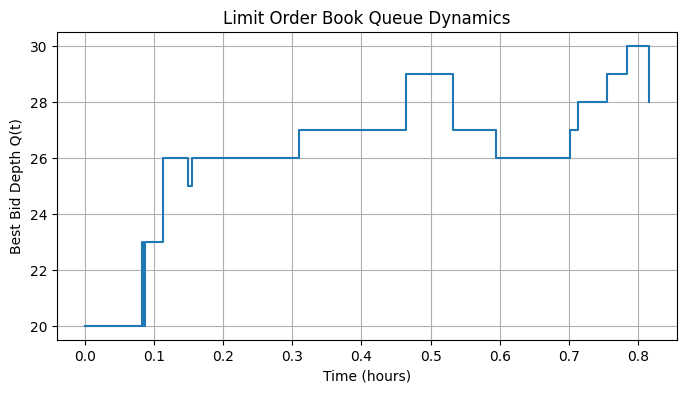

In [8]:
plt.figure(figsize=(8,4))
plt.step(times, queue, where="post")
plt.xlabel("Time (hours)")
plt.ylabel("Best Bid Depth Q(t)")
plt.title("Limit Order Book Queue Dynamics")
plt.grid(True)
plt.show()